In [1]:
import mlflow
import pandas as pd
mlflow.set_tracking_uri("../mlruns")
experiment_id = "914879025403898454"

In [2]:
unscaled_runs = ['b5d0631da9134f35b9e8ac9a3ae4eb13',
                   '10600ab2700044cc925b1d1b6f436b44', 'ccccaec6a30b420196903e7a164ce790', '71f7c1d03d964787ae3b6824c3e9bba7', '15f0bb9b035c4849a015003e51cceb26', '7ce0fd142657458cbd9a221a9dd35f39', '7e998f7dd4784a63901d0c7127f13da4', 'b6545bc12c7246dbb734e9576b645067', '6ff2223d307a4f1c8040180ff48691e1', '7313a9acc55e4de19fac50da44f96372', 'c273604ca80145bba520e88908dad7b1', '60be9a2064f2449c9dcef1bc12cf68e6']
scaled_runs=["317e6c8db4114e9784aa0150cd015047","05e4e6888a85461bacf5508598b61679","4df775c7e6134311b2e4d4169dd6f07c","0eadb949a65d4ad89cfc9af420957c60","5dc563640bbe49118449105893f551d8","fa49a7502f2c4fd79cb00ac83c3497a0","22cf6c2c9d7f4d6d963c521ea3f33c3f","df218d18679440c59128e6825d605db7","e751ef2411c74775b630d37030b289f3","16ff5296993442c689fb21eca5cfe9b8","902cfe63adc64d4e8d16047aca0fdbaa","6b6029a4f33e44f9bf482e33c058081f"]
cospgd_run = ['e2eca6bf1c204bdf925786dcf260fb20']

In [3]:
client = mlflow.tracking.MlflowClient()
ids_str = ", ".join(f"'{run}'" for run in unscaled_runs+scaled_runs)  # Оборачиваем каждое значение в одинарные кавычки
filter_string = f"attributes.run_id IN ({ids_str})"  # Формируем финальный запрос
runs = mlflow.search_runs(experiment_ids=[experiment_id], filter_string=filter_string)
runs['params.use_map_scaling'].fillna(False, inplace=True)

In [8]:
runs[runs['params.target_layer'] == 'update_block.mask']['run_id'].to_list()

['317e6c8db4114e9784aa0150cd015047',
 '0eadb949a65d4ad89cfc9af420957c60',
 '22cf6c2c9d7f4d6d963c521ea3f33c3f',
 '16ff5296993442c689fb21eca5cfe9b8',
 'b5d0631da9134f35b9e8ac9a3ae4eb13',
 '71f7c1d03d964787ae3b6824c3e9bba7',
 '7e998f7dd4784a63901d0c7127f13da4',
 '7313a9acc55e4de19fac50da44f96372']

In [43]:
runs['params.use_map_scaling']

0      True
1      True
2      True
3      True
4      True
5      True
6      True
7      True
8      True
9      True
10     True
11     True
12    False
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
21    False
22    False
23    False
Name: params.use_map_scaling, dtype: object

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import numpy as np


def plot_alpha_vs_aee(runs_data, metric='mean_aee_target_attack_step_'):
    if not isinstance(runs_data, pd.DataFrame):
        raise ValueError("runs_data must be a pandas DataFrame")

    # Determine the keyword in the metric name for title adjustment
    if "target" in metric:
        metric_label = "target flow"
    elif "init" in metric:
        metric_label = "initial flow"
    elif "gt" in metric:
        metric_label = "ground truth"
    else:
        metric_label = metric.replace("_", " ")  # Default to metric name

    # Copy and preprocess data
    runs_data = runs_data.copy()
    runs_data["params.alpha"] = runs_data["params.alpha"].astype(float)
    runs_data["params.no_softmax"] = runs_data["params.no_softmax"].astype(str)

    # Ensure categorical values for consistent grouping
    runs_data["params.target_layer"] = runs_data["params.target_layer"].astype(
        str)
    runs_data["params.use_map_scaling"] = runs_data["params.use_map_scaling"].astype(
        bool)

    # Group by attack type
    epsilon_groups = runs_data.groupby("params.epsilon")

    # Get unique (target_layer, use_map_scaling) combinations
    unique_target_layers = sorted(runs_data["params.target_layer"].unique())

    # Assign colors based on unique target layers
    colors = plt.cm.viridis(np.linspace(0, 1, len(unique_target_layers)))
    color_map = {layer: colors[idx]
                 for idx, layer in enumerate(unique_target_layers)}

    # Define marker styles for map scaling
    # Square for map scaling, Circle otherwise
    marker_styles = {True: "s", False: "o"}

    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=(20, 12))
    axes = axes.flatten()

    fig.suptitle(
        f'Comparison of Mean AEE to {metric_label} on Kitti15 for different epsilon',
        fontsize=16
    )

    eps_map = {0.00392: '1/255', 0.00784: '2/255',
               0.01568: '4/255', 0.03137: '8/255'}
    
    for idx, (epsilon, group) in enumerate(epsilon_groups):
        ax = axes[idx]
        epsilon = float(epsilon)
        eps_frac = eps_map.get(epsilon, str(epsilon))
        ax.set_title(
            f'Epsilon: {eps_frac} vs Mean AEE to {metric_label}', fontsize=14)
        ax.set_xlabel('Number of Iterations in attack', fontsize=12)
        ax.set_ylabel(
            f'Mean AEE between {metric_label} and attacked flow', fontsize=12)

        for _, row in group.iterrows():
            target_layer = row["params.target_layer"]
            use_map_scaling = row["params.use_map_scaling"]

            # Select color based on target layer
            color = color_map[target_layer]

            # Select marker based on use_map_scaling
            marker = marker_styles[use_map_scaling]

            # Extract attack steps and metric values
            values = {}
            for column, value in row.items():
                if column.startswith('metrics.' + metric):
                    step_number = re.search(r'(\d+)$', column)
                    if step_number:
                        step_number = int(step_number.group(1))
                        values[step_number] = value

            # Sort values by step number
            sorted_items = sorted(values.items())
            sorted_steps = [key for key, _ in sorted_items]
            sorted_metrics = [value for _, value in sorted_items]

            legend_label = f"Layer: {target_layer}, Map Scaling: {use_map_scaling}"
            ax.plot(
                sorted_steps, sorted_metrics, linestyle="-", marker=marker,
                label=legend_label, color=color, markersize=8
            )

        ax.legend()
        ax.grid(True)

    plt.tight_layout()
    plt.show()

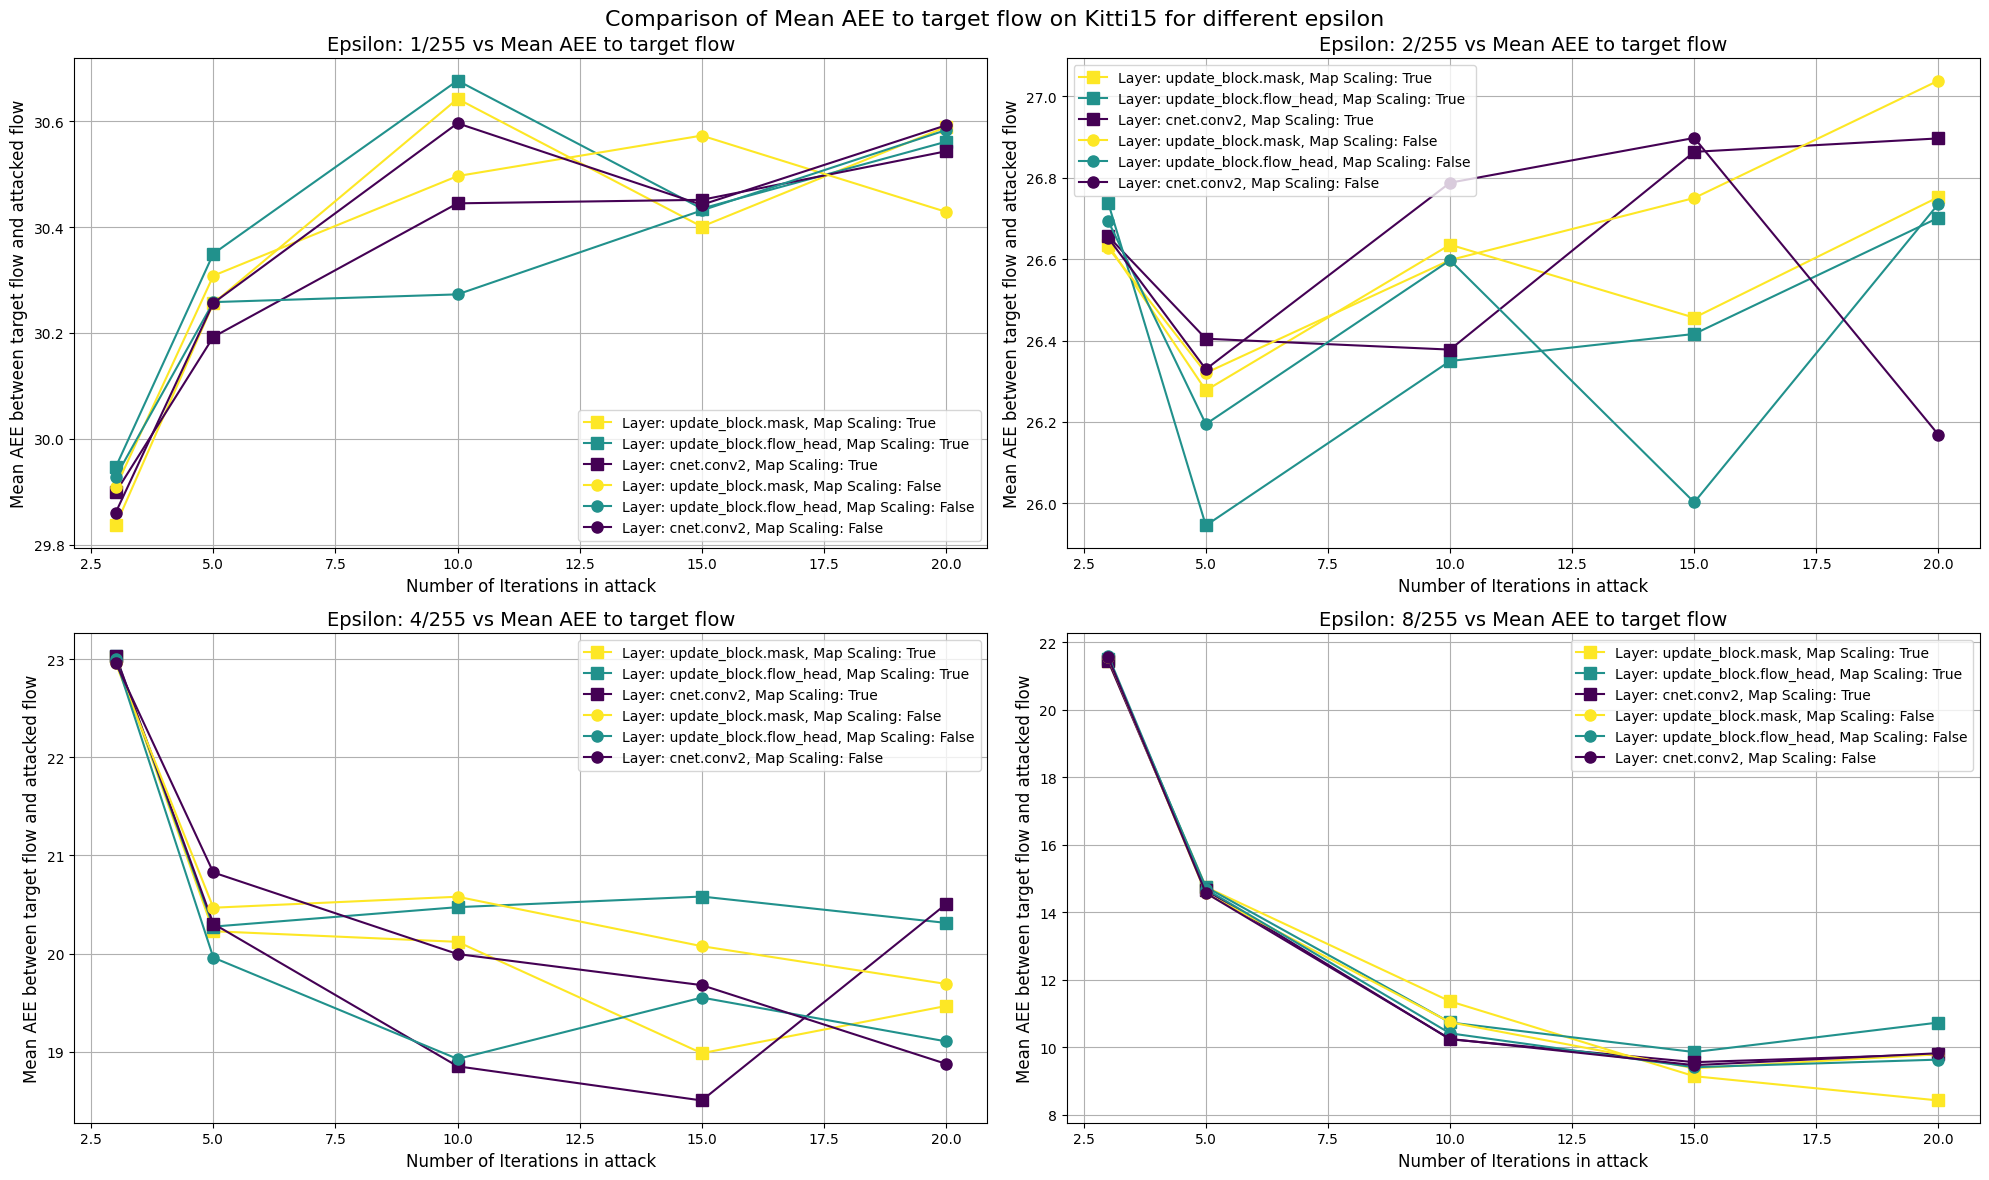

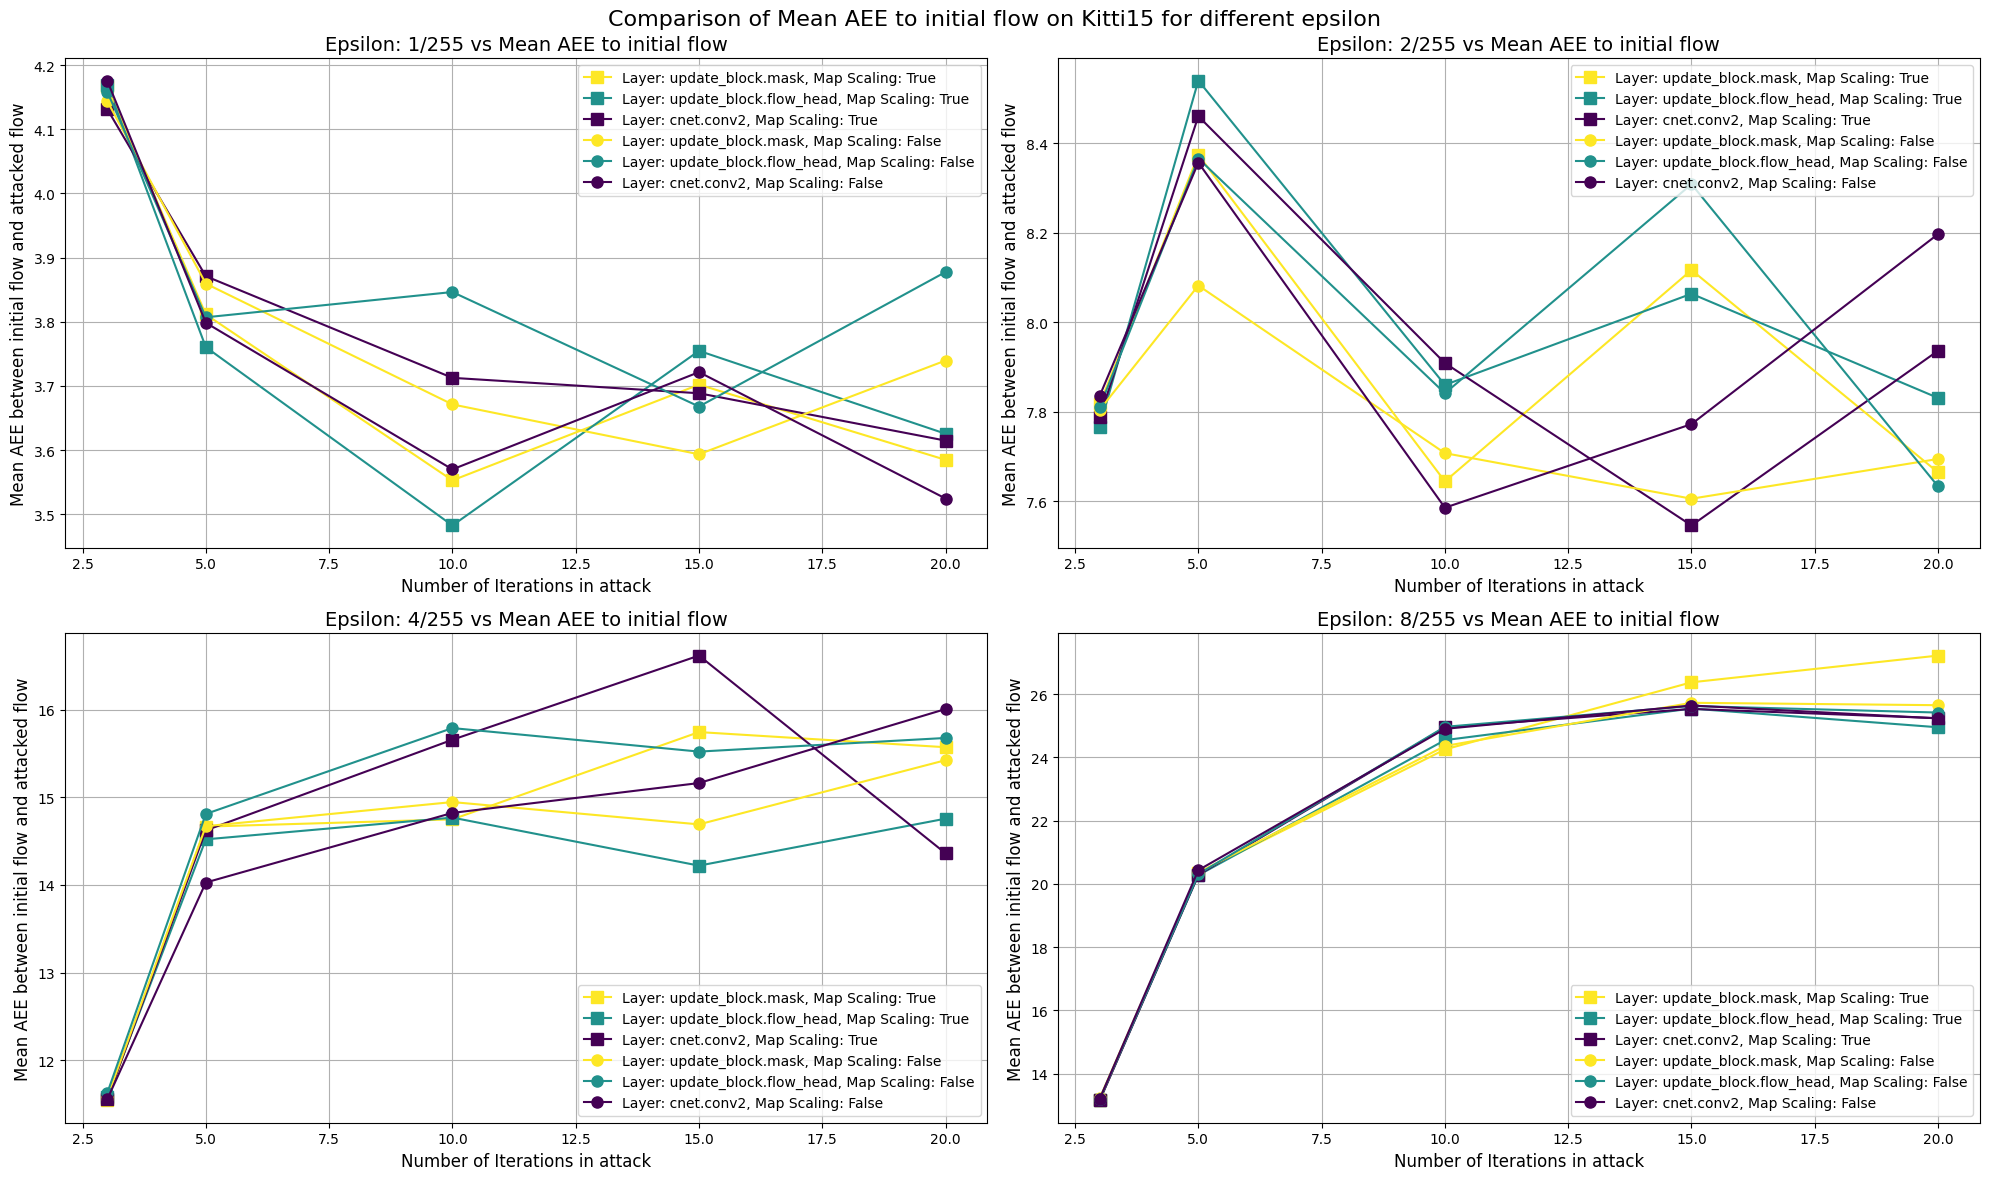

In [53]:
plot_alpha_vs_aee(runs)
plot_alpha_vs_aee(runs, 'mean_aee_init_attack_step_')

In [71]:
scaled_sobel = ["26bf0e21c69b4dbe9a16f88eeb9e7b74","48d5830bb1ed4393ae8c841696e8227a","e52db5db440742a9a100c47f735ac395","1e3feb5e7a624f4ebc26601d1ed7821f"]
unscaled_sobel = ["c0686835bbb54b9081a73db33bb90d8e", "ba2036068b6a451d9ad18680b75ead7d",
                 "c45bfbecba464ddab686a5b22c0c2267", "508235141bcf46648f6f136935448d7a"]

scaled_highfreq = ["7d85dafc00d840ef9ee7053575d9e206", "3489cbd789064918bf97ffe4adca3695","5f8e00885f6e4d509c15ba573dc7da9c","9e195fee13ab419a8d8737e5955d06b2"]
unscaled_highfreq = ['950484a899d647bcbc48930d12ebda33', '5c74451d4bca4200b2f93c03ff15d337',
                     '8db7b02cbee44e5da2328348ad3e45f5',	'fd198de526c4487489f4c9e8731fc33d']

gradcam = ['317e6c8db4114e9784aa0150cd015047',
           '0eadb949a65d4ad89cfc9af420957c60',
           '22cf6c2c9d7f4d6d963c521ea3f33c3f',
           '16ff5296993442c689fb21eca5cfe9b8',
           'b5d0631da9134f35b9e8ac9a3ae4eb13',
           '71f7c1d03d964787ae3b6824c3e9bba7',
           '7e998f7dd4784a63901d0c7127f13da4',
           '7313a9acc55e4de19fac50da44f96372']
cospgd = ['ec158121700644a9834201ce31e79dec', 'e2eca6bf1c204bdf925786dcf260fb20',
                  '65229fc8582946dcac32ebf4c82e93b8', '453f6881f37647c1886e2bb292831ecf']

In [72]:
client = mlflow.tracking.MlflowClient()
# Оборачиваем каждое значение в одинарные кавычки
ids_str = ", ".join(f"'{run}'" for run in scaled_sobel+scaled_highfreq)
# Формируем финальный запрос
filter_string = f"attributes.run_id IN ({ids_str})"
scaled_runs = mlflow.search_runs(
    experiment_ids=[experiment_id], filter_string=filter_string)
scaled_runs['params.use_map_scaling'].fillna(False, inplace=True)

In [73]:
scaled_runs['params.use_map_scaling'] = True

In [74]:
ids_str = ", ".join(f"'{run}'" for run in unscaled_sobel+unscaled_highfreq+gradcam+cospgd)
# Формируем финальный запрос
filter_string = f"attributes.run_id IN ({ids_str})"
unscaled_runs = mlflow.search_runs(
    experiment_ids=[experiment_id], filter_string=filter_string)


In [75]:
runs = pd.concat([scaled_runs, unscaled_runs], axis=0)
runs['params.use_map_scaling'].fillna(False, inplace=True)

In [76]:
runs.loc[runs['run_id'].isin(unscaled_highfreq),'params.attack_type'] = 'HighFreq'

In [87]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import numpy as np


def plot_alpha_vs_aee_for_scaled(runs_data, metric='mean_aee_target_attack_step_'):
    if not isinstance(runs_data, pd.DataFrame):
        raise ValueError("runs_data must be a pandas DataFrame")

    # Determine the keyword in the metric name for title adjustment
    if "target" in metric:
        metric_label = "target flow"
    elif "init" in metric:
        metric_label = "initial flow"
    elif "gt" in metric:
        metric_label = "ground truth"
    else:
        metric_label = metric.replace("_", " ")  # Default to metric name

    # Copy and preprocess data
    runs_data = runs_data.copy()
    runs_data["params.alpha"] = runs_data["params.alpha"].astype(float)
    runs_data["params.no_softmax"] = runs_data["params.no_softmax"].astype(str)

    # Ensure categorical values for consistent grouping
    runs_data["params.target_layer"] = runs_data["params.target_layer"].astype(
        str)
    runs_data["params.use_map_scaling"] = runs_data["params.use_map_scaling"].astype(
        bool)

    # Group by attack type
    epsilon_groups = runs_data.groupby("params.epsilon")

    # Get unique (target_layer, use_map_scaling) combinations
    unique_target_layers = sorted(runs_data["params.attack_type"].unique())

    # Assign colors based on unique target layers
    colors = plt.cm.viridis(np.linspace(0, 1, len(unique_target_layers)))
    color_map = {layer: colors[idx]
                 for idx, layer in enumerate(unique_target_layers)}

    # Define marker styles for map scaling
    # Square for map scaling, Circle otherwise
    marker_styles = {True: "s", False: "o"}
    line_styles = {True: '-', False: '--'}
    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=(20, 12))
    axes = axes.flatten()

    fig.suptitle(
        f'Comparison of Mean AEE to {metric_label} on Kitti15 for different epsilon',
        fontsize=16
    )

    eps_map = {0.00392: '1/255', 0.00784: '2/255',
               0.01568: '4/255', 0.03137: '8/255'}

    for idx, (epsilon, group) in enumerate(epsilon_groups):
        ax = axes[idx]
        epsilon = float(epsilon)
        eps_frac = eps_map.get(epsilon, str(epsilon))
        ax.set_title(
            f'Epsilon: {eps_frac} vs Mean AEE to {metric_label}', fontsize=14)
        ax.set_xlabel('Number of Iterations in attack', fontsize=12)
        ax.set_ylabel(
            f'Mean AEE between {metric_label} and attacked flow', fontsize=12)

        for _, row in group.iterrows():
            target_layer = row["params.attack_type"]
            use_map_scaling = row["params.use_map_scaling"]

            # Select color based on target layer
            color = color_map[target_layer]

            # Select marker based on use_map_scaling
            marker = marker_styles[use_map_scaling]
            line_style = line_styles[use_map_scaling]
            # Extract attack steps and metric values
            values = {}
            for column, value in row.items():
                if column.startswith('metrics.' + metric):
                    step_number = re.search(r'(\d+)$', column)
                    if step_number:
                        step_number = int(step_number.group(1))
                        if step_number <= 20:
                            values[step_number] = value

            # Sort values by step number
            sorted_items = sorted(values.items())
            sorted_steps = [key for key, _ in sorted_items]
            sorted_metrics = [value for _, value in sorted_items]

            legend_label = f"Attack: {target_layer}, Map Scaling: {use_map_scaling}"
            ax.plot(
                sorted_steps, sorted_metrics, linestyle=line_style, marker='o',
                label=legend_label, color=color, markersize=8
            )

        ax.legend()
        ax.grid(True)

    plt.tight_layout()
    plt.show()

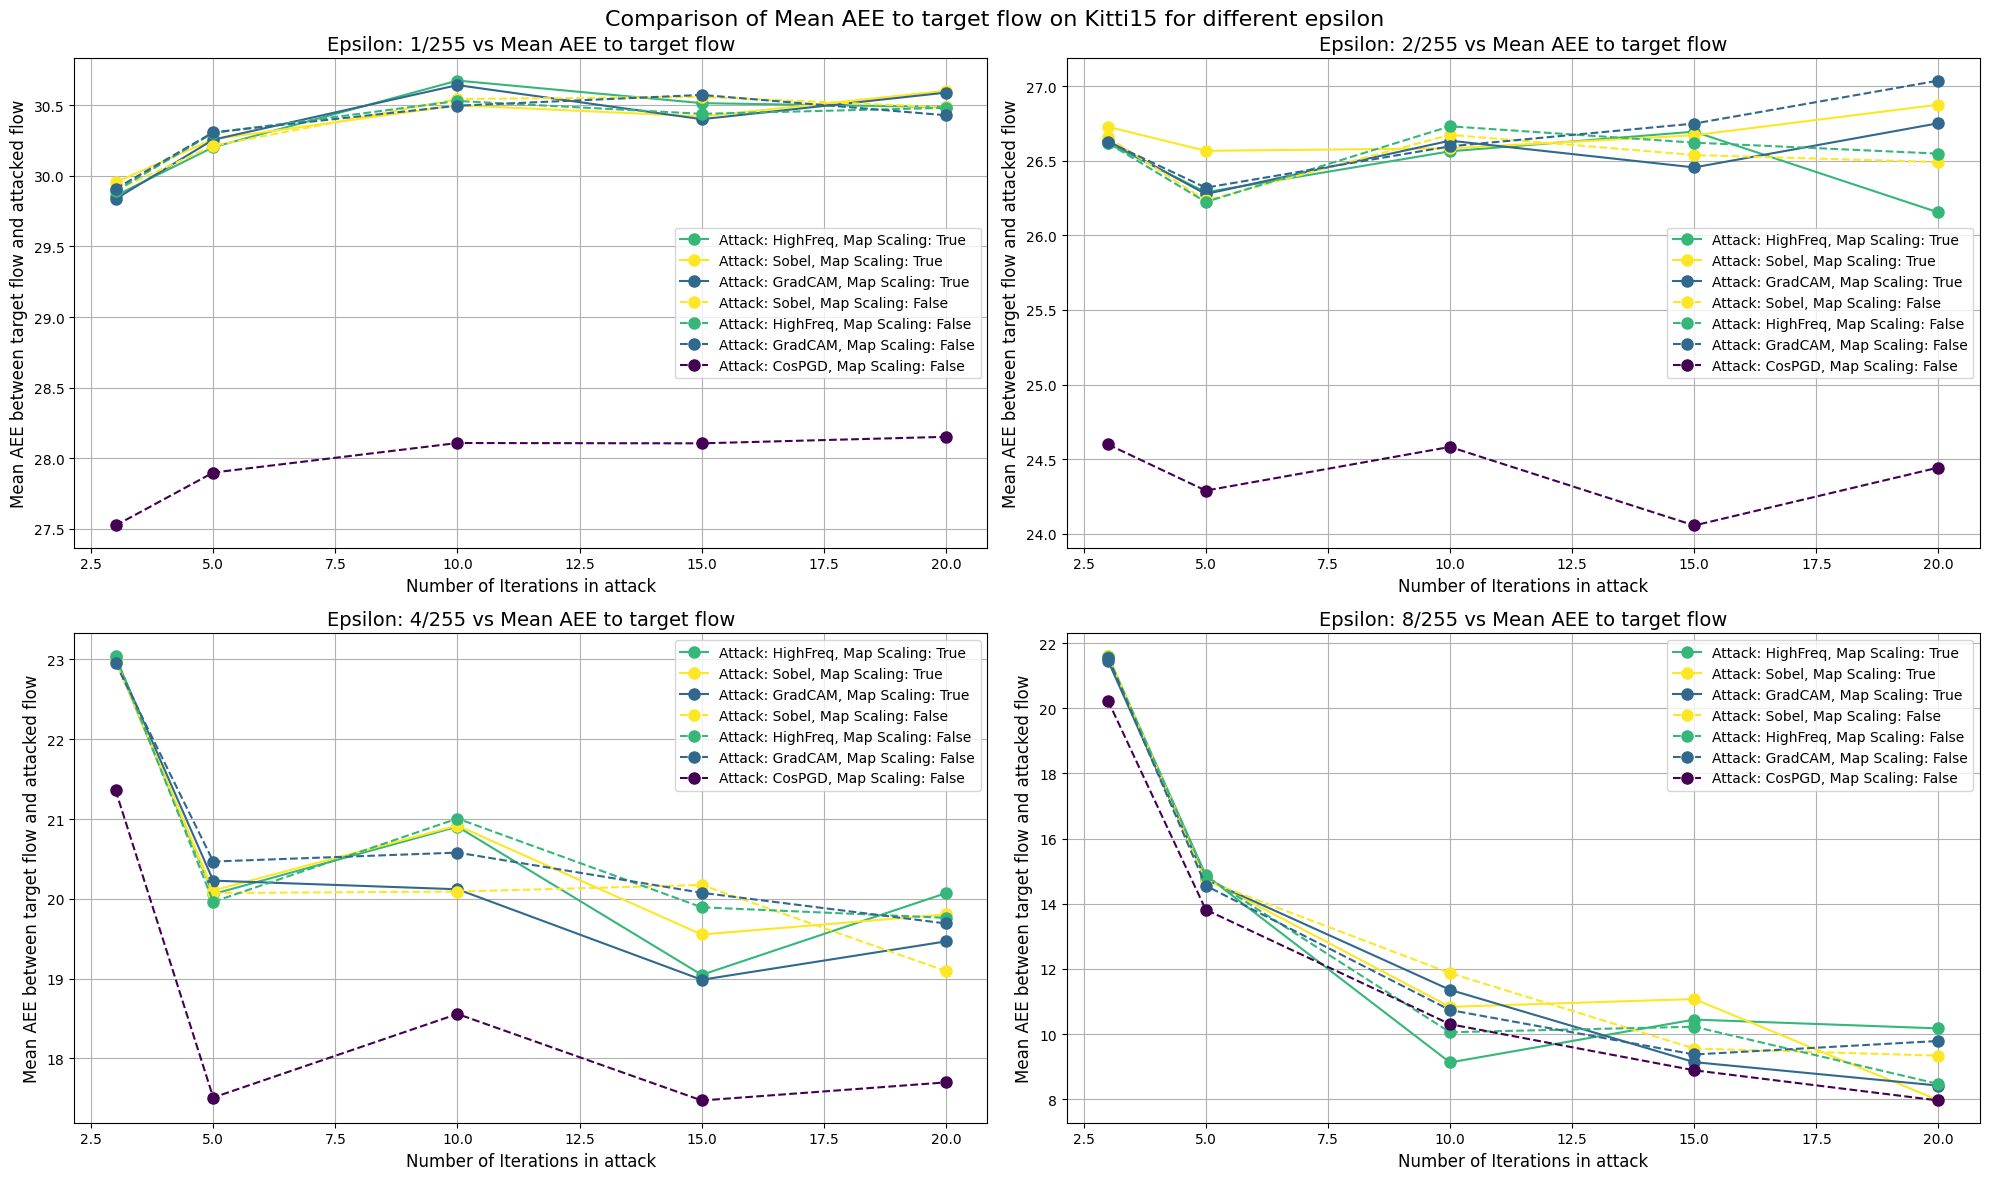

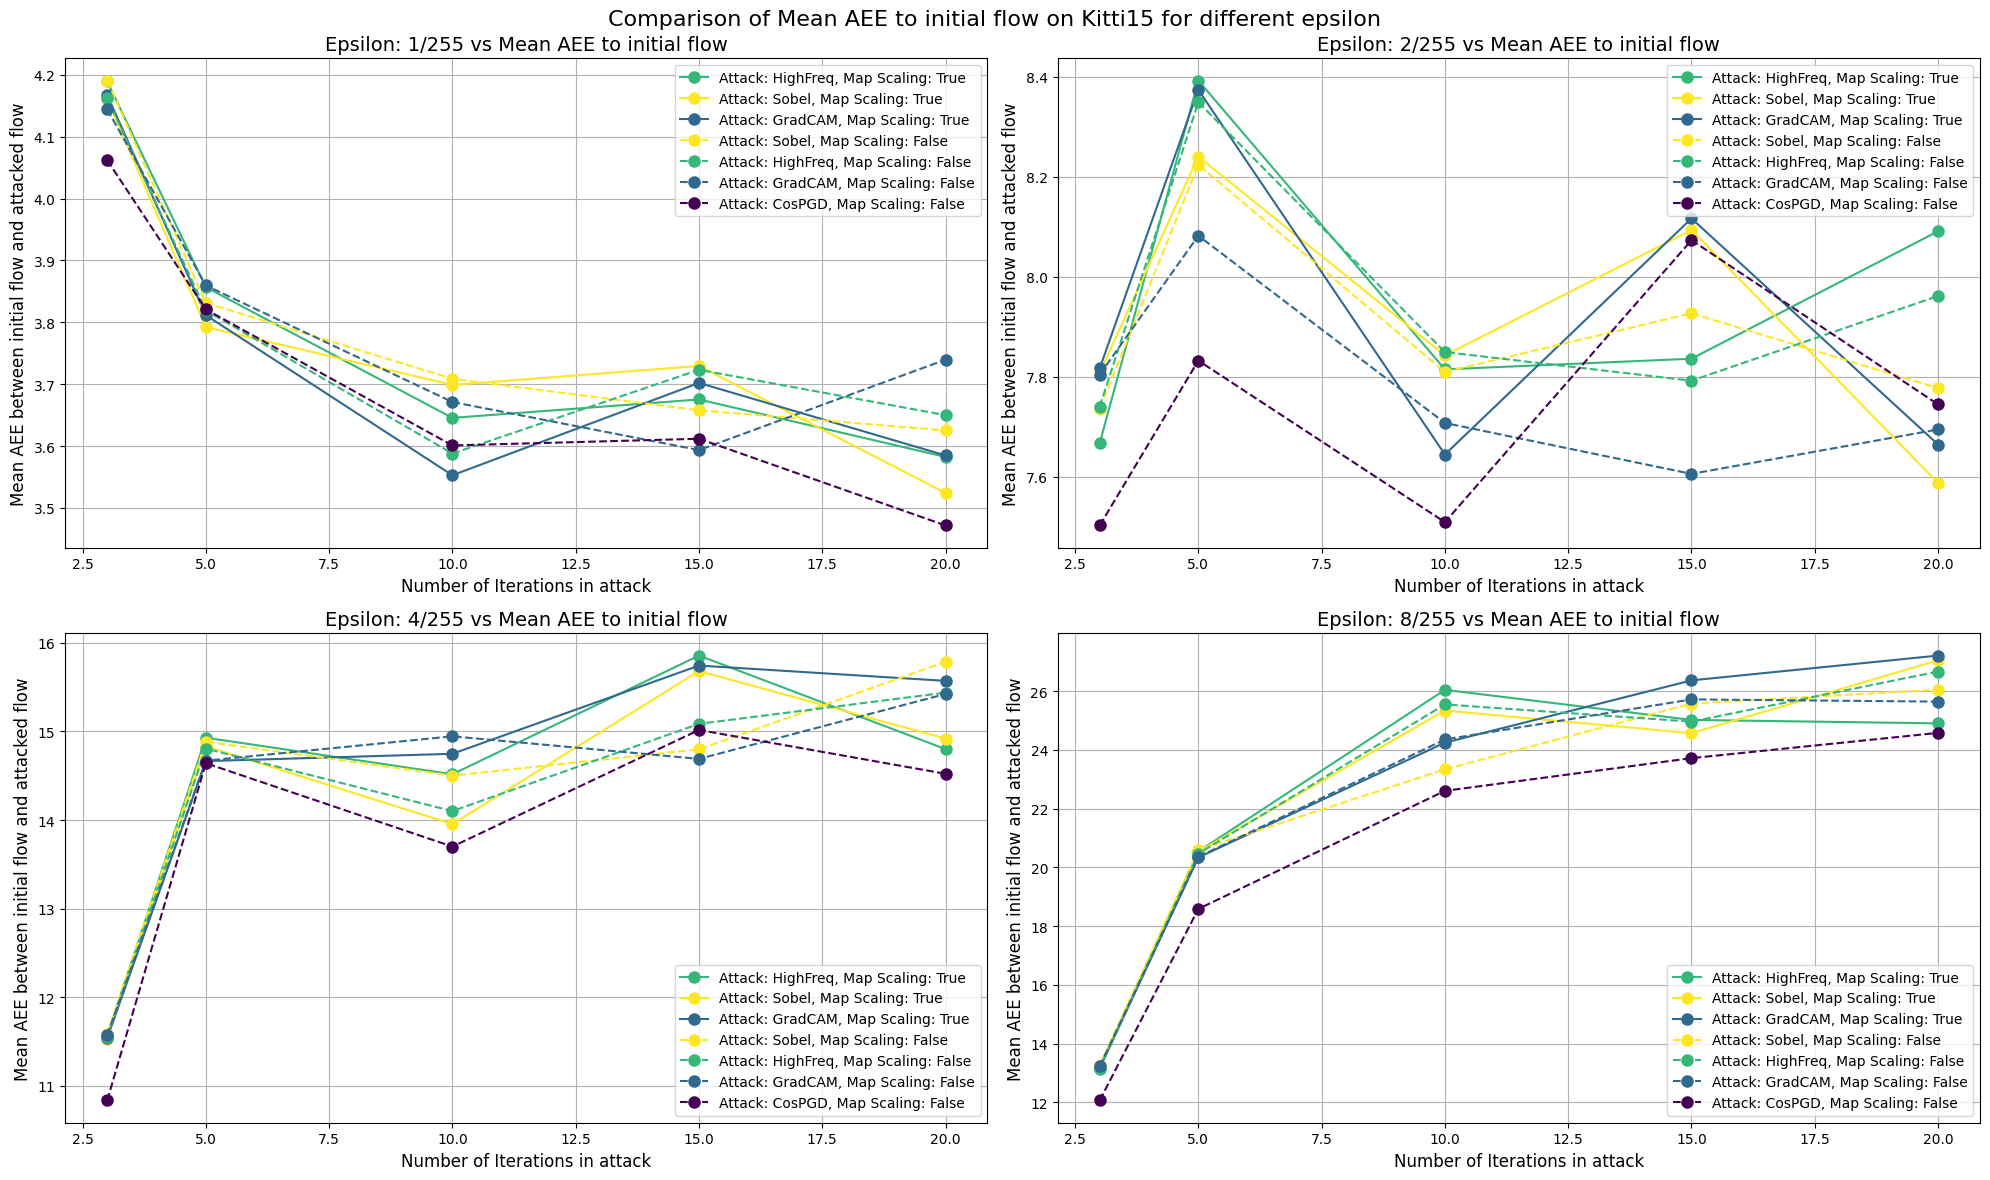

In [88]:
plot_alpha_vs_aee_for_scaled(runs)
plot_alpha_vs_aee_for_scaled(runs, 'mean_aee_init_attack_step_')